# Análisis Exploratorio de Datos (EDA) - Detección de Fraude en Seguros de Auto

Este dataset contiene información sobre pólizas de seguro, perfiles de clientes, características de vehículos y detalles de siniestros automovilísticos. El objetivo principal es identificar patrones que diferencien los reclamos legítimos de los fraudulentos (`fraud_reported`).

---

## Contenido

1. [Clasificación y Explicación de las Columnas](#1-explicacion)
2. [Análisis Inicial](#2-analisis)
3. [Relación con el Fraude](#3-rel_fraude)
4. [Pasos que faltan para profundizar](#4-temporal)


In [24]:
# Cargamos librerias necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime
from scipy import stats
from scipy.stats import mannwhitneyu, norm
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import anderson
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

from matplotlib.animation import FuncAnimation
rng = np.random.default_rng()
x = stats.uniform.rvs(size=75, random_state=rng)
sns.set(style="darkgrid")

In [4]:
# Cargamos la base de datos
df = pd.read_csv('insurance_claims.csv')

In [5]:
# Realizamos un primer vistazo a la base de datos
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,17/10/2014,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,27/06/2006,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,06/09/2000,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,25/05/1990,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,06/06/2014,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [6]:
# Obtenemos características generales de la base de datos
print(f'La base de datos tiene {df.shape[0]} filas y {df.shape[1]} columnas')
print(f"{'Columnas':>30} | {'Tipo de Dato'}")
for col in df.columns:
    print(f"{col:>30} | {df[col].dtype}")

df = df.drop(columns= "_c39")

La base de datos tiene 1000 filas y 40 columnas
                      Columnas | Tipo de Dato
            months_as_customer | int64
                           age | int64
                 policy_number | int64
              policy_bind_date | object
                  policy_state | object
                    policy_csl | object
             policy_deductable | int64
         policy_annual_premium | float64
                umbrella_limit | int64
                   insured_zip | int64
                   insured_sex | object
       insured_education_level | object
            insured_occupation | object
               insured_hobbies | object
          insured_relationship | object
                 capital-gains | int64
                  capital-loss | int64
                 incident_date | object
                 incident_type | object
                collision_type | object
             incident_severity | object
         authorities_contacted | object
                incident_state | 

In [7]:
# Esto ayuda a verificar que total_claim_amount se componga de las demás columnas.
df['siniestralidad_total'] = df['injury_claim'] + df['property_claim'] + df['vehicle_claim']
(df['siniestralidad_total'] == df['total_claim_amount']).sum()

np.int64(1000)

---

<a id='1-explicacion'></a>
## 1. Clasificación y Explicación de las Columnas


Con el primer vistazo, identificamos que en total tenemos 1000 registros de los cuales se obtienen 40 variables, las cuales definiremos aqui para comprender su relevancia analítica.

### A. Perfil del asegurado
* **`months_as_customer` (Meses como cliente) y `age` (Edad):** Permiten analizar la lealtad y el perfil demográfico. Ayudan a entender si los clientes más jóvenes o más nuevos presentan comportamientos de reclamo diferentes.
* **`insured_sex`, `insured_education_level`, `insured_occupation`, `insured_relationship`:** Variables demográficas estándar para segmentación. Permiten evaluar si el perfil socioeconómico influye en la siniestralidad.
* **`insured_hobbies` (Pasatiempos):** Variable conductual. Ciertos pasatiempos pueden estar correlacionados con perfiles de riesgo más altos o patrones inusuales en siniestros.
* **`capital-gains` (Ganancias de capital) y `capital-loss` (Pérdidas de capital):** 

### B. Detalles de la Póliza
* **`policy_number` e `insured_zip`:** Identificadores únicos
* **`policy_bind_date` (Fecha de emisión de póliza):** Crucial para calcular la antigüedad de la póliza al momento del accidente. (Reclamos muy cercanos a la fecha de contratación podrian ser alerta de fraude.)
* **`policy_state` (Estado de la póliza):** Distribución geográfica de la cartera.
* **`policy_csl` (Límites de responsabilidad combinados):** Define la cobertura máxima de la póliza por categoria **(Revisar si los montos vienen en millones/miles)**.
* **`policy_deductable` (Deducible):** Monto que el cliente paga de su bolsillo. 
* **`policy_annual_premium` (Prima anual):** Costo de la póliza. 
* **`umbrella_limit` (Límite de póliza):** Cobertura de responsabilidad civil adicional.

### C. Detalles del Incidente / Siniestro
* **`incident_date` (Fecha del incidente):** Permite evaluar factores de estacionalidad temporal (mes, día de la semana).
* **`incident_type` (Tipo de incidente) y `collision_type` (Tipo de colisión):** Clasifican la naturaleza del siniestro **(Tipo de colision tiene registros '?', verificar a qué se debe)**.
* **`incident_severity` (Gravedad del incidente):** Los daños calificados como menores o mayores deben guardar relación directa con los costos del reclamo.
* **`incident_hour_of_the_day` (Hora del día):** La severidad se podria ver asociada con la hora del día en que ocurrio el siniestro.
* **`incident_state`, `incident_city`, `incident_location`:** Ubicación geográfica del evento para detectar zonas de alta siniestralidad o fraude concentrado.
* **`authorities_contacted` (Autoridades contactadas) y `police_report_available` (Reporte policial disponible):** La ausencia de intervención policial en incidentes severos representa una anomalía grave.
* **`number_of_vehicles_involved` (Vehículos involucrados) y `witnesses` (Testigos):** Ayudan a corroborar la consistencia física del relato del accidente.
* **`property_damage` (Daño a propiedad) y `bodily_injuries` (Lesiones corporales):** Indicadores de la magnitud de los daños colaterales.

### D. Costos del Reclamo (Variables Financieras)
* **`total_claim_amount` (Monto total del reclamo):** La variable económica principal, se segrega en las siguientes variables:
  * `injury_claim` (Reclamo por lesiones).
    * `property_claim` (Reclamo por daños a la propiedad).
      * `vehicle_claim` (Reclamo por daños al vehículo asegurado).
### E. Datos del Vehículo
  * **`auto_make` (Marca), `auto_model` (Modelo), `auto_year` (Año):** Determinan el valor comercial y el costo de refacciones.

### F. Variable Objetivo y Columnas a Descartar
  * **`fraud_reported` (Fraude reportado):** La variable objetivo. Todo el EDA girará en torno a cómo el resto de las variables interactúan con esta.
  * **`_c39`:** Columna residual sin información útil generada comúnmente por errores de delimitación en la carga del archivo. **Debe ser eliminada.**




---
<a id='2-analisis'></a>
# 2 Análisis inicial (Comprender el comportamiento de la cartera)

### Análisis perfil asegurados 

La mayoría de las variables presentan una distribución relativamente uniforme, ya que las frecuencias son similares entre las diferentes categorías. Por otro lado, las variables de ganancia y pérdida de capital muestran una distribución sesgada, concentrando mayor parte de los datos en valores cercanos a cero.

La distribución por edad/sexo muestra una mayor concentración de asegurados en edades medias y avanzadas que en edades jóvenes, se observa un comportamiento similar al de una población envejecida, característica de muchos países europeos.




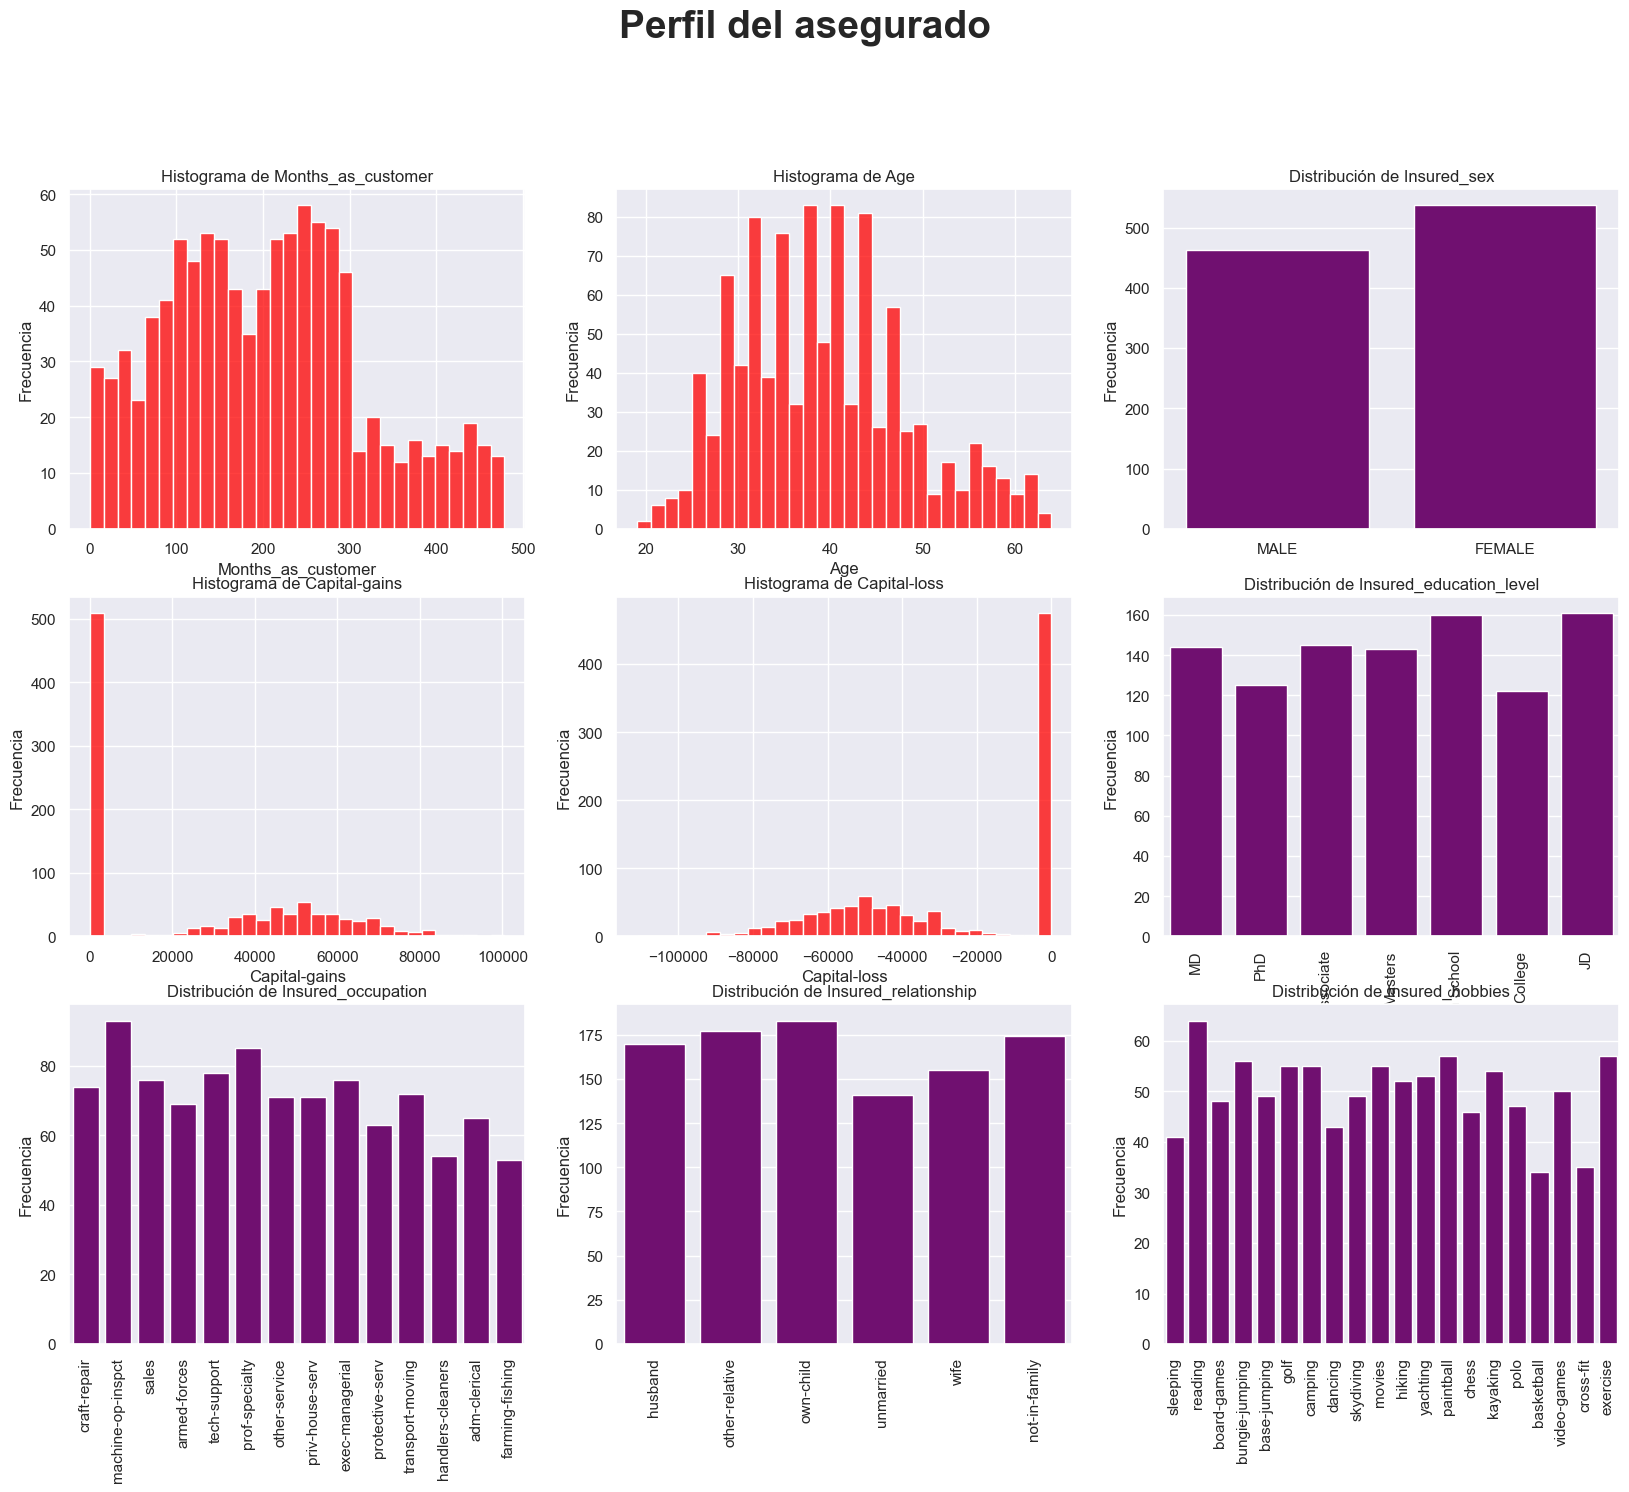

In [8]:
#Gráficas para el perfil del asegurado:
variables = ['months_as_customer', 'age', 'insured_sex', 'capital-gains', 'capital-loss', 'insured_education_level', 
             'insured_occupation',  'insured_relationship', 'insured_hobbies']
df_filtrado = df[variables]


fig, axes= plt.subplots(nrows = 3, ncols = 3,figsize=(20, 15))
axes = axes.flatten()

for i, var in enumerate(variables):
    # Trabajamos sobre el eje correspondiente
    ax = axes[i]  
    
    # Si la variable es categórica, hacemos un grafico de barras
        # Si hay varias categorias rotamos las etiquetas
    if df_filtrado[var].dtype == "object":
        if df_filtrado[var].nunique() > 5:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )

            ax.tick_params(axis='x', rotation=90)
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
        else:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
    # Si la variable es numérica, hacemos un histograma
    else:
        # Calcular los bins automáticamente para variables numéricas/discretas
        bins_choise = (
            len(df_filtrado[var].unique())
            if "año" in var or "fecha" in var or df_filtrado[var].nunique() < 10
            else 30
        )
        sns.histplot(
            data=df_filtrado, 
            x=var, 
            bins=bins_choise, 
            ax=ax, 
            color = "red"
        )
        # Ajustamos títulos y etiquetas
        ax.set_title(f"Histograma de {var.capitalize()}")
        ax.set_xlabel(var.capitalize())
        ax.set_ylabel("Frecuencia")
    
    # Quitamos la leyenda individual de cada gráfico para que no estorbe
    if ax.get_legend():
        ax.get_legend().remove()

fig.suptitle("Perfil del asegurado", 
             fontsize=28, fontweight='bold', x=0.4, ha='left', y=1)

plt.show()

In [9]:
# Datos de ejemplo
bins = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45,
        50, 55, 60, 65, 70, 75, 80, 200]

labels = ['0-4', '5-9', '10-14', '15-19', '20-24',
          '25-29', '30-34', '35-39', '40-44',
          '45-49', '50-54', '55-59', '60-64',
          '65-69', '70-74', '75-79', '80+']

df['grupo_edad'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    right=False
)

tabla = (
    df.groupby(['grupo_edad', 'insured_sex'])
      .size()
      .unstack(fill_value=0)
)

tabla

C:\Users\ismae\AppData\Local\Temp\ipykernel_19940\3298953080.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['grupo_edad', 'insured_sex'])


insured_sex,FEMALE,MALE
grupo_edad,,
0-4,0,0
5-9,0,0
10-14,0,0
15-19,1,0
20-24,17,8
25-29,64,65
30-34,123,82
35-39,114,81
40-44,100,96


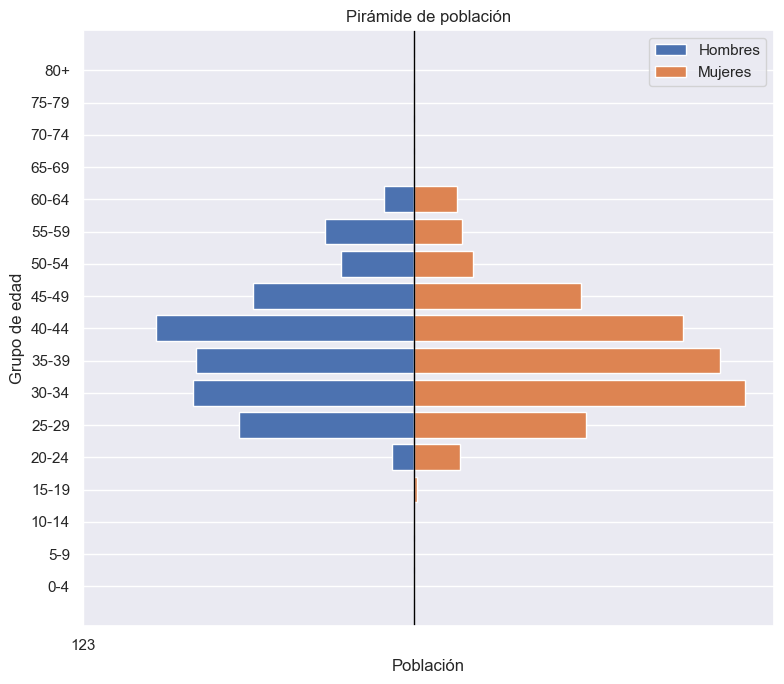

In [ ]:


df = pd.DataFrame({
    "edad": ["0-4", "5-9", "10-14", "15-19", "20-24", "25-29",
             "30-34", "35-39", "40-44", "45-49", "50-54", "55-59",
             "60-64", "65-69", "70-74", "75-79", "80+"],
    "hombres": tabla['MALE'],
    "mujeres": tabla['FEMALE']
})

# Convertimos hombres a negativo para que aparezcan a la izquierda
df["hombres_neg"] = -df

plt.figure(figsize=(8, 7))

plt.barh(df["edad"], df_grupo_edad["hombres_neg"], label="Hombres")
plt.barh(df_grupo_edad["edad"], df_grupo_edad["mujeres"], label="Mujeres")

plt.axvline(0, color="black", linewidth=1)

plt.title("Pirámide de población")
plt.xlabel("Población")
plt.ylabel("Grupo de edad")

# Para que el eje x muestre valores positivos en ambos lados
max_val = max(df_grupo_edad["hombres"].max(), df_grupo_edad["mujeres"].max())
ticks = range(-max_val, max_val + 1, 500)
plt.xticks(ticks, [abs(t) for t in ticks])

plt.legend()
plt.tight_layout()
plt.show()

### Análisis Detalles de la Póliza 

De acuerdo al histograma del año de emisión, se observa

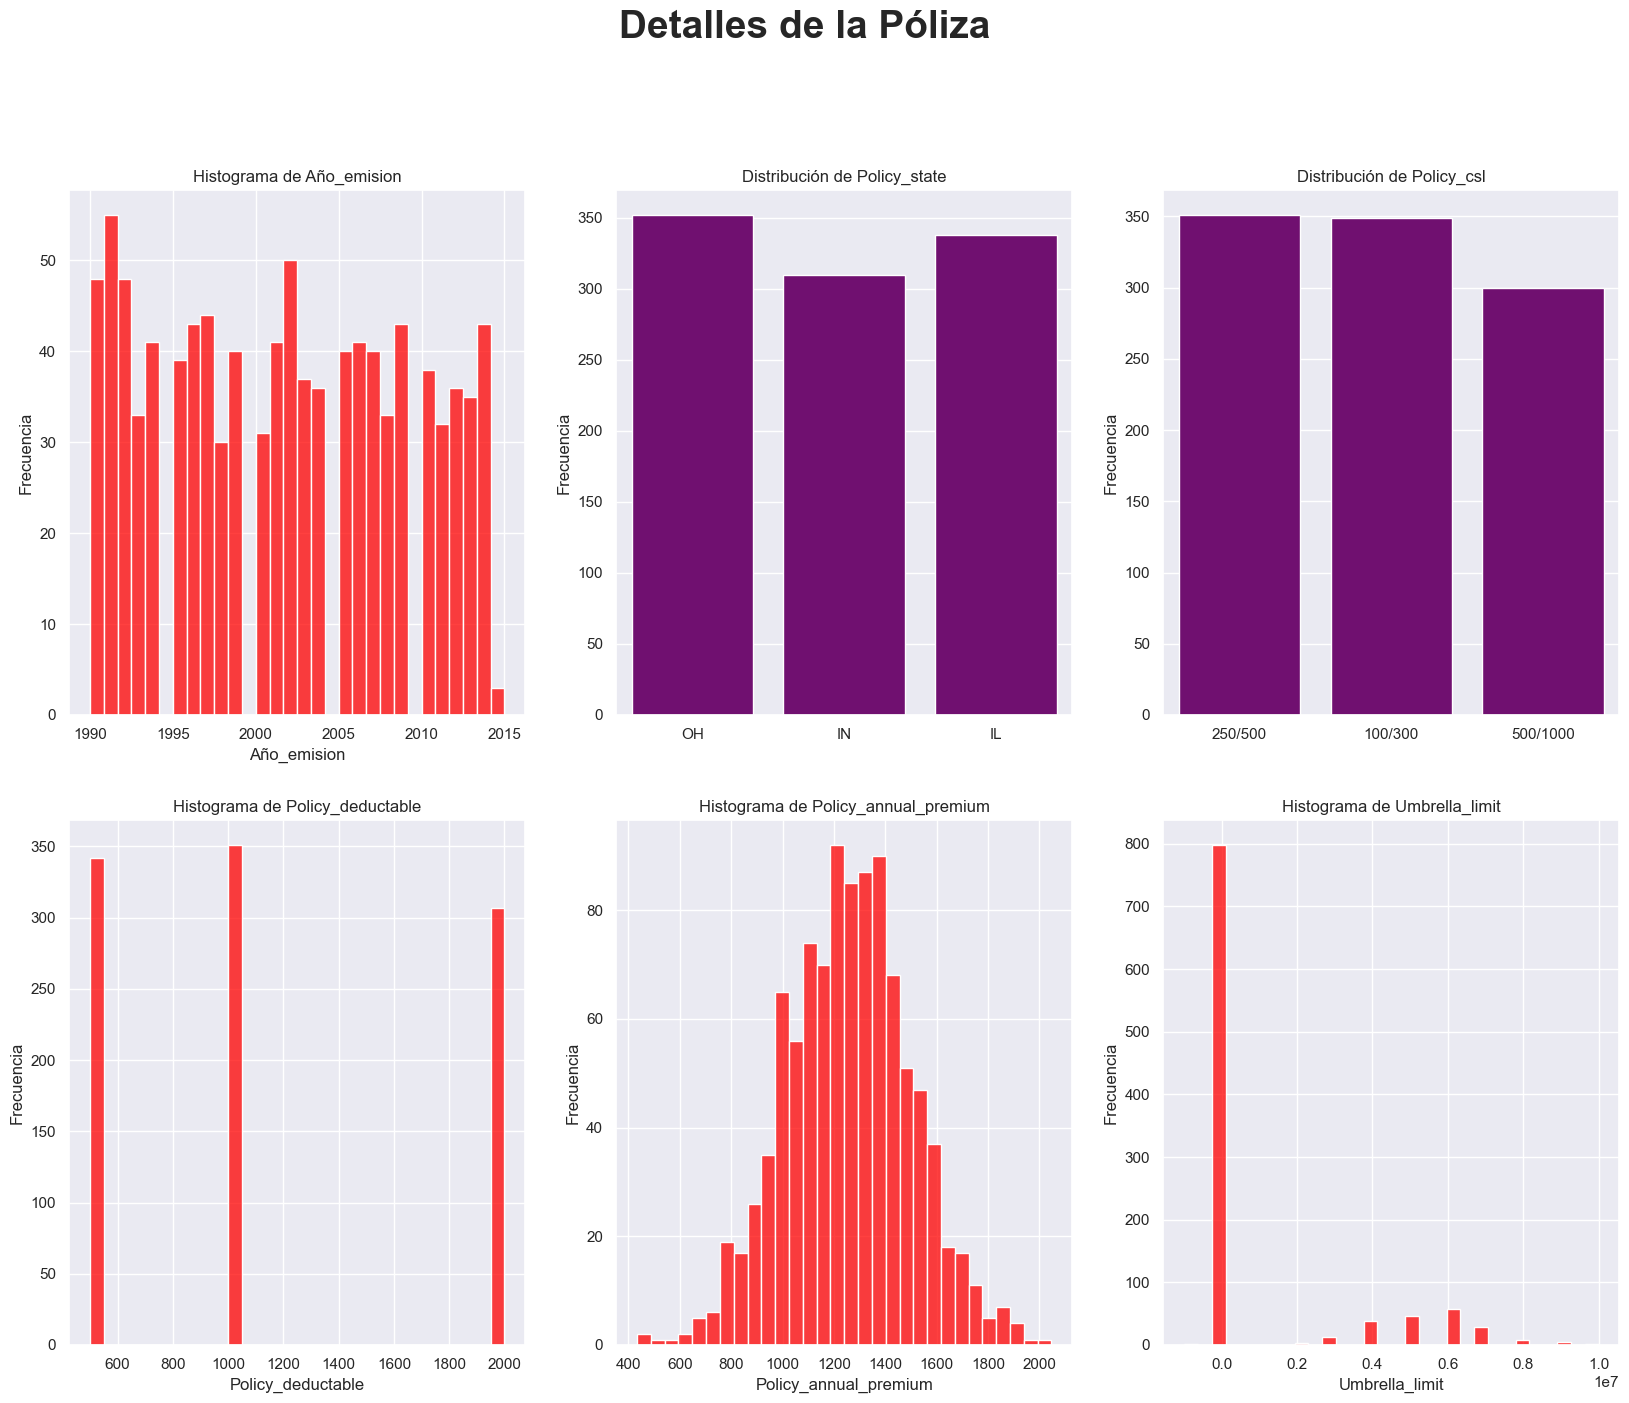

In [13]:
# Gráficas para detalles de la póliza:
df["Año_Emision"] = pd.to_datetime(df["policy_bind_date"], format='%d/%m/%Y', errors="coerce").dt.year

variables = ["Año_Emision", "policy_state", "policy_csl", "policy_deductable", "policy_annual_premium", "umbrella_limit"]
df_filtrado = df[variables]   # <-- también aquí


fig, axes= plt.subplots(nrows = 2, ncols = 3,figsize=(20, 15))
axes = axes.flatten()

for i, var in enumerate(variables):
    # Trabajamos sobre el eje correspondiente
    ax = axes[i]  
    # Si la variable es categórica, hacemos un grafico de barras
        # Si hay varias categorias rotamos las etiquetas
    if df_filtrado[var].dtype == "object":
        if df_filtrado[var].nunique() > 5:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )

            ax.tick_params(axis='x', rotation=90)
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
        else:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
    # Si la variable es numérica, hacemos un histograma
    else:
        # Calcular los bins automáticamente para variables numéricas/discretas
        bins_choise = (
            len(df_filtrado[var].unique())
            if "año" in var or "fecha" in var or df_filtrado[var].nunique() < 2
            else 30
        )
        sns.histplot(
            data=df_filtrado, 
            x=var, 
            bins=bins_choise, 
            ax=ax, 
            color = "red"
        )
        # Ajustamos títulos y etiquetas
        ax.set_title(f"Histograma de {var.capitalize()}")
        ax.set_xlabel(var.capitalize())
        ax.set_ylabel("Frecuencia")
    
    # Quitamos la leyenda individual de cada gráfico para que no estorbe
    if ax.get_legend():
        ax.get_legend().remove()

fig.suptitle("Detalles de la Póliza", 
             fontsize=28, fontweight='bold', x=0.4, ha='left', y=1)

plt.show()

### Análisis Detalles del Siniestro (AGREGAR)

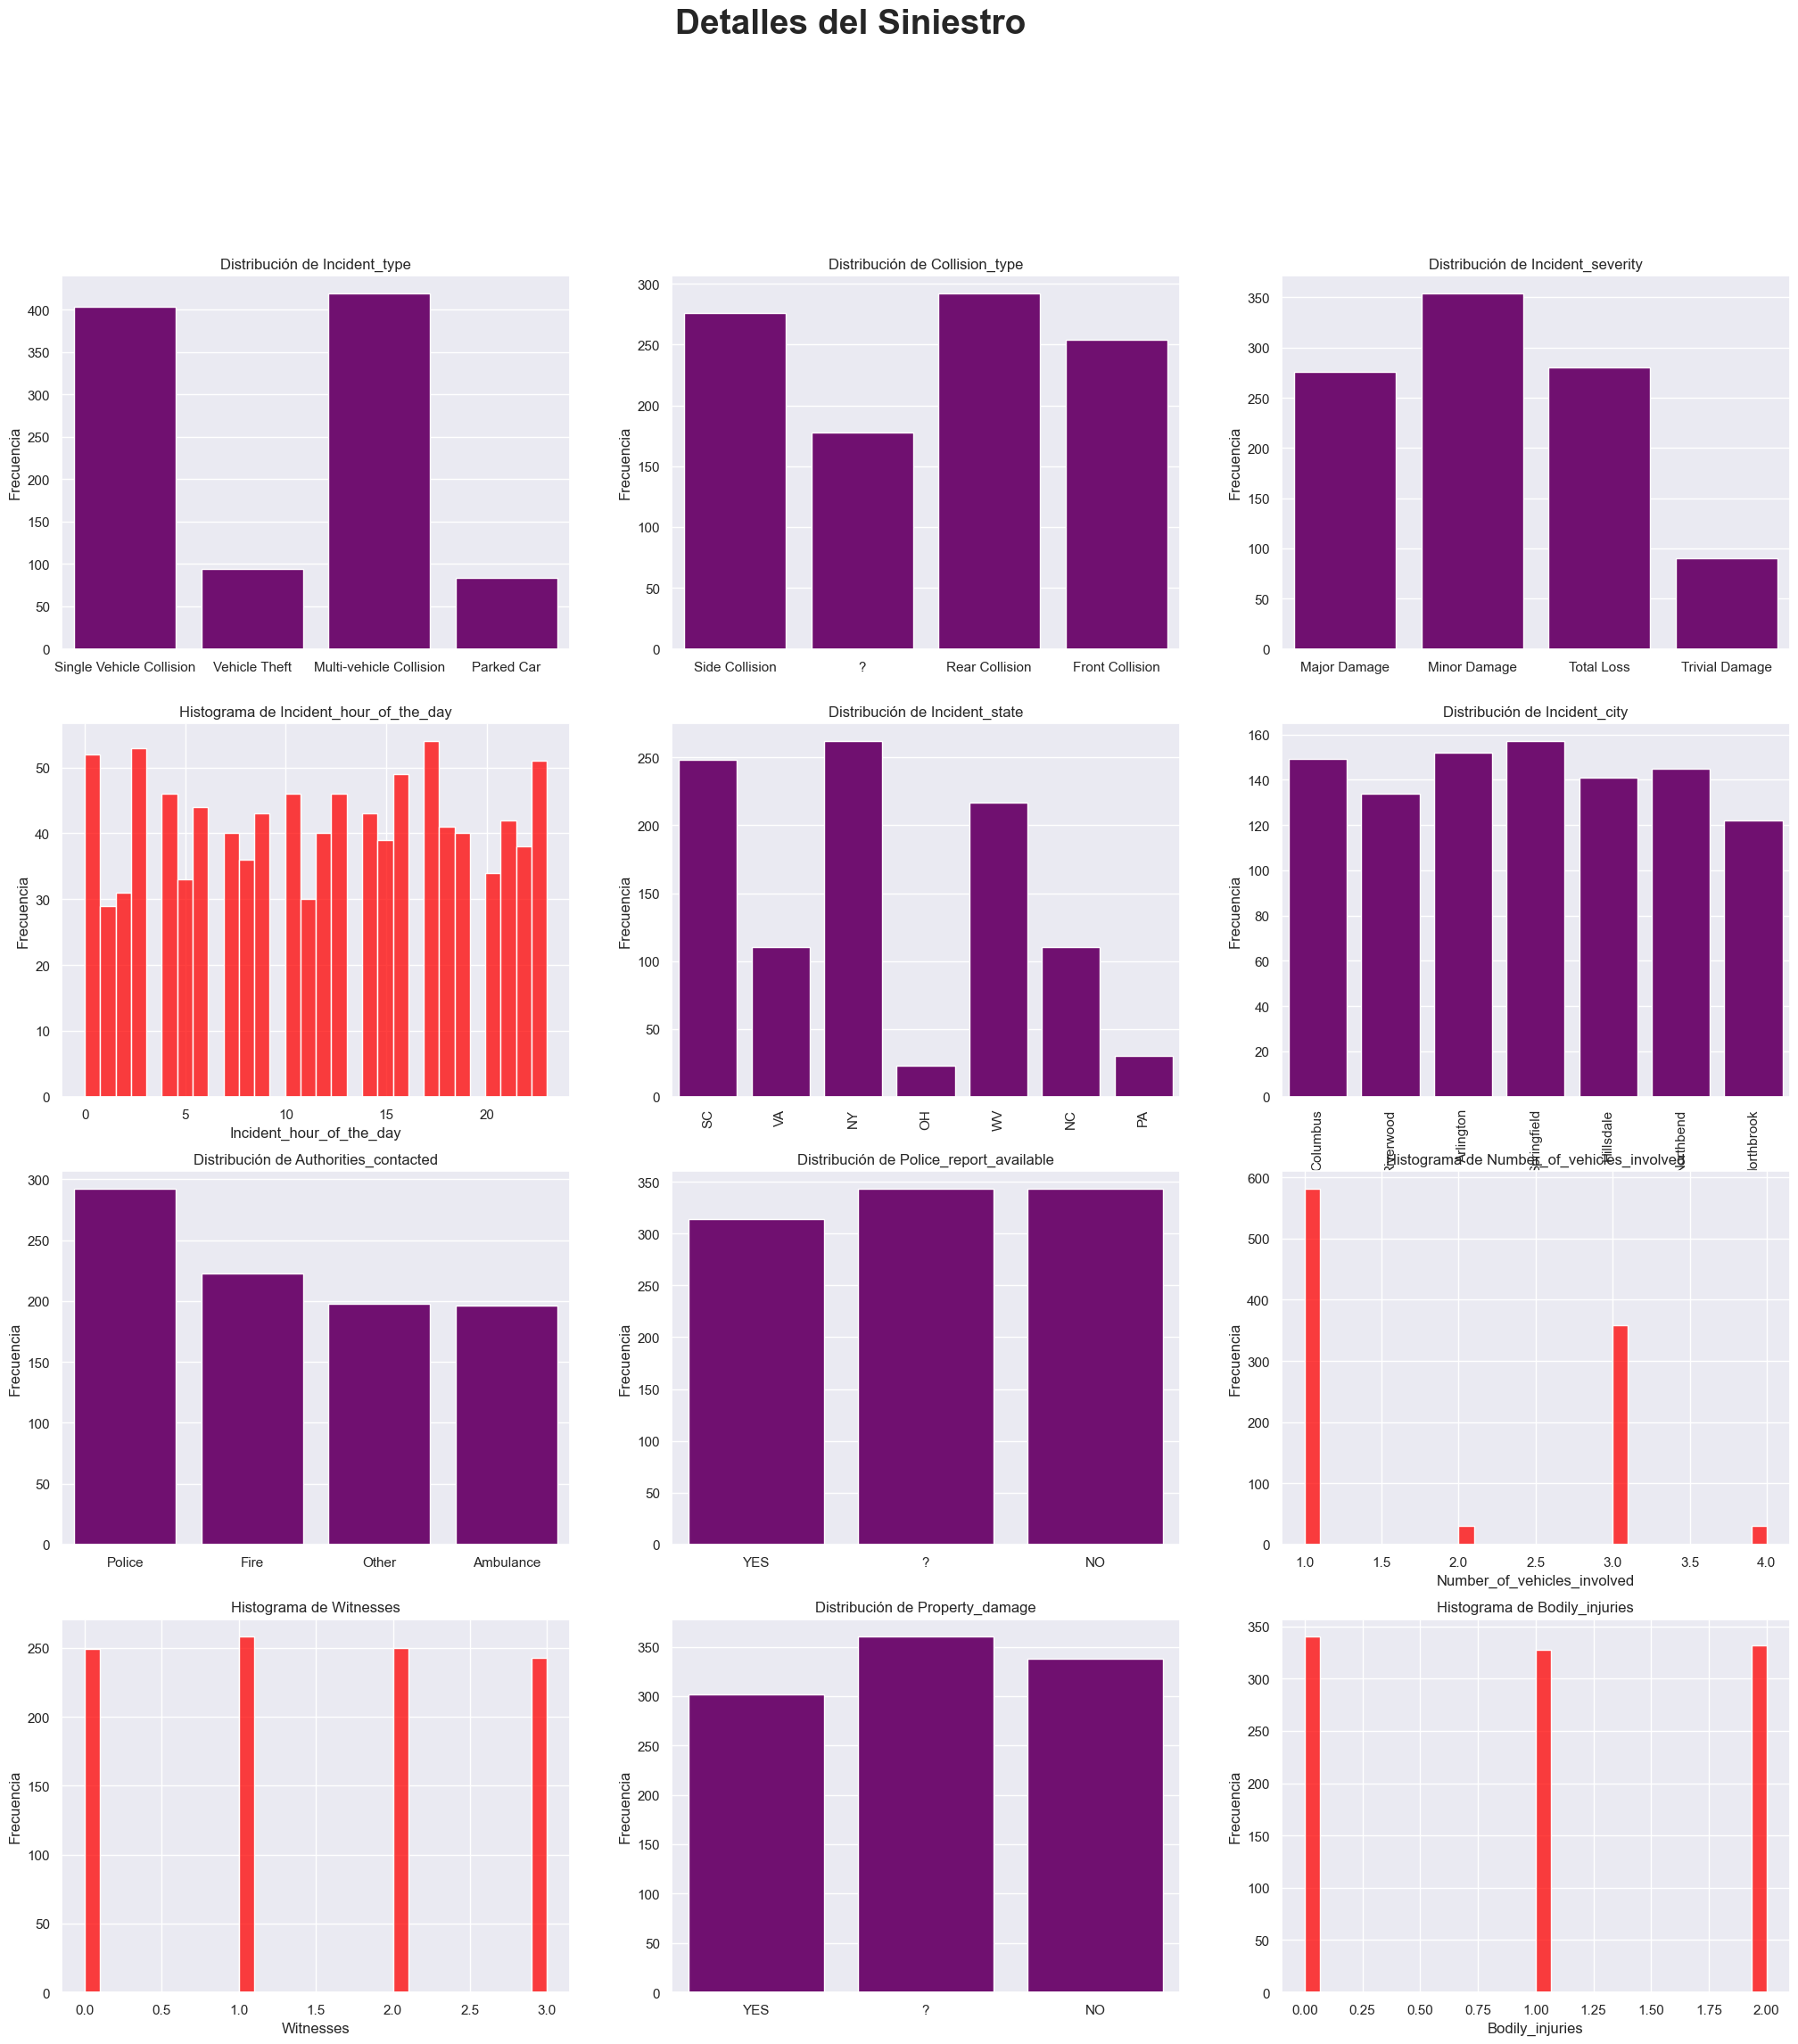

In [14]:
#Gráficas para detalles del Siniestro:
variables = ["incident_type","collision_type", "incident_severity","incident_hour_of_the_day","incident_state","incident_city",
             "authorities_contacted","police_report_available", "number_of_vehicles_involved", "witnesses", "property_damage", "bodily_injuries"]
df_filtrado = df[variables]


fig, axes= plt.subplots(nrows = 4, ncols = 3,figsize=(25, 25))
axes = axes.flatten()

for i, var in enumerate(variables):
    # Trabajamos sobre el eje correspondiente
    ax = axes[i]  
    # Si la variable es categórica, hacemos un grafico de barras
        # Si hay varias categorias rotamos las etiquetas
    if df_filtrado[var].dtype == "object":
        if df_filtrado[var].nunique() > 5:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )

            ax.tick_params(axis='x', rotation=90)
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
        else:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
    # Si la variable es numérica, hacemos un histograma
    else:
        # Calcular los bins automáticamente para variables numéricas/discretas
        bins_choise = (
            len(df_filtrado[var].unique())
            if "año" in var or "fecha" in var or df_filtrado[var].nunique() < 2
            else 30
        )
        sns.histplot(
            data=df_filtrado, 
            x=var, 
            bins=bins_choise, 
            ax=ax, 
            color = "red"
        )
        # Ajustamos títulos y etiquetas
        ax.set_title(f"Histograma de {var.capitalize()}")
        ax.set_xlabel(var.capitalize())
        ax.set_ylabel("Frecuencia")
    
    # Quitamos la leyenda individual de cada gráfico para que no estorbe
    if ax.get_legend():
        ax.get_legend().remove()

fig.suptitle("Detalles del Siniestro", 
             fontsize=28, fontweight='bold', x=0.4, ha='left', y=1)

plt.show()

### Análisis Costos del Reclamo (AGREGAR)

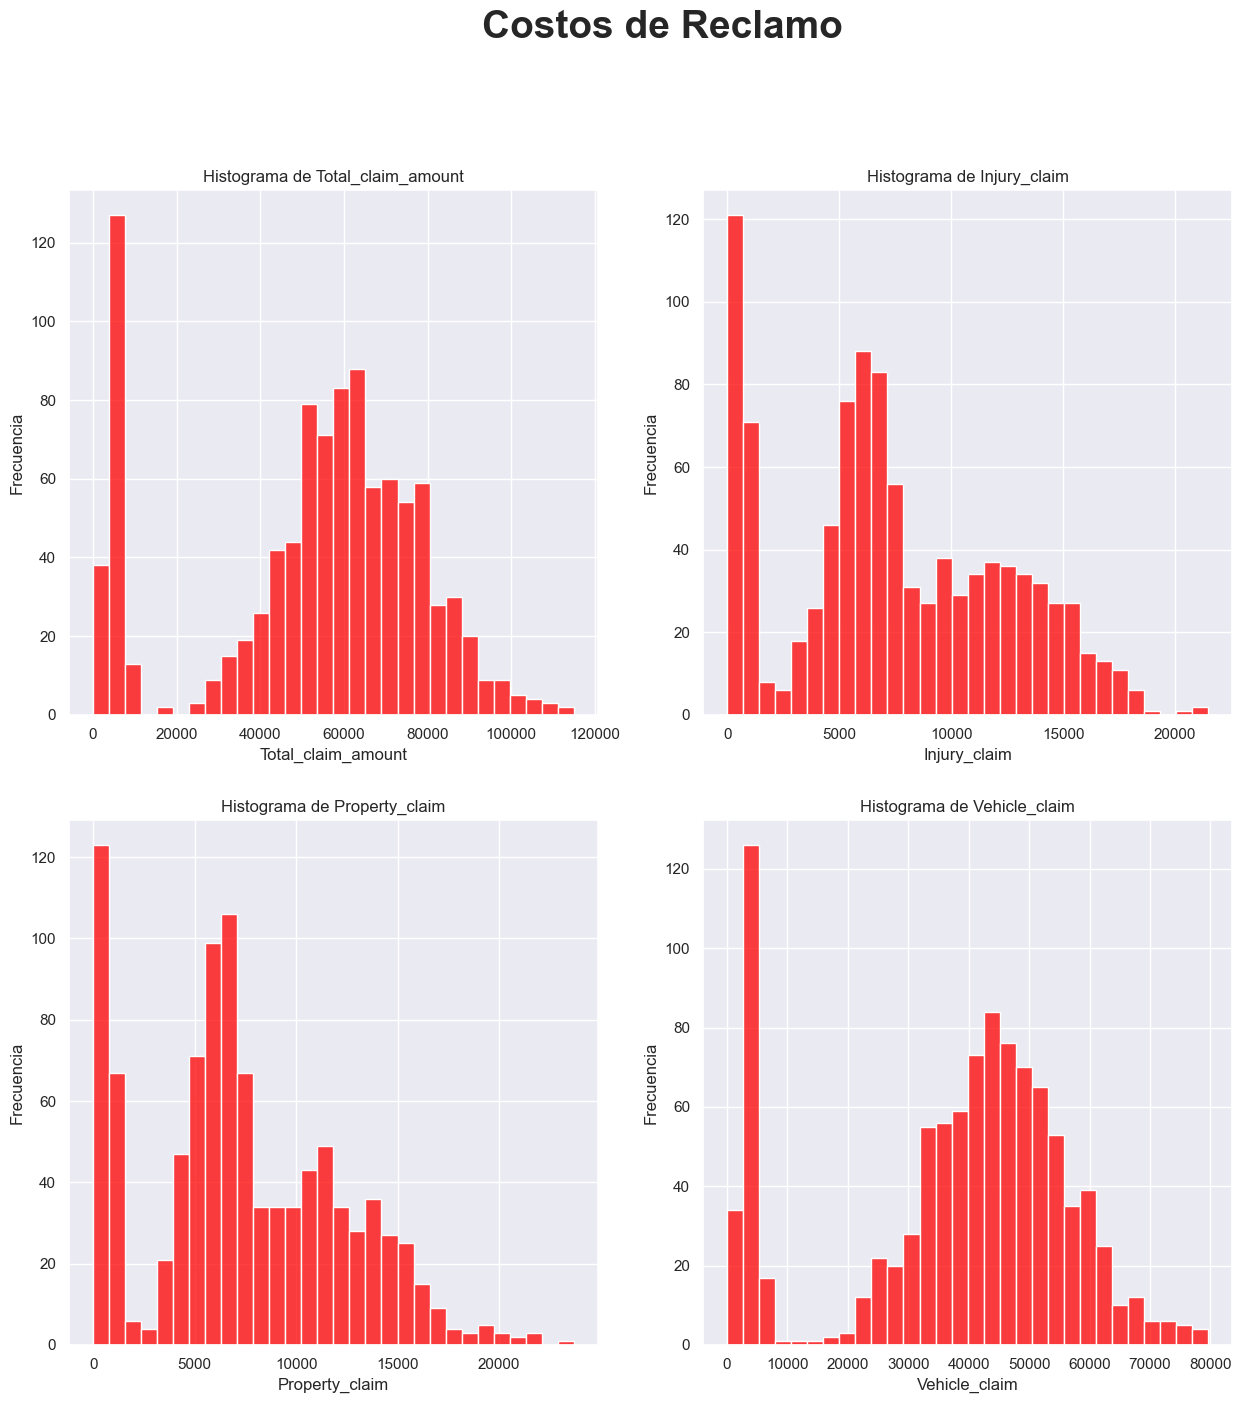

In [15]:
#Gráficas para Costos del Reclamo:
variables = ["total_claim_amount", "injury_claim", "property_claim", "vehicle_claim"]
df_filtrado = df[variables]


fig, axes= plt.subplots(nrows = 2, ncols = 2,figsize=(15, 15))
axes = axes.flatten()

for i, var in enumerate(variables):
    # Trabajamos sobre el eje correspondiente
    ax = axes[i]  
    # Si la variable es categórica, hacemos un grafico de barras
        # Si hay varias categorias rotamos las etiquetas
    if df_filtrado[var].dtype == "object":
        if df_filtrado[var].nunique() > 5:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )

            ax.tick_params(axis='x', rotation=90)
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
        else:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
    # Si la variable es numérica, hacemos un histograma
    else:
        # Calcular los bins automáticamente para variables numéricas/discretas
        bins_choise = (
            len(df_filtrado[var].unique())
            if "año" in var or "fecha" in var or df_filtrado[var].nunique() < 2
            else 30
        )
        sns.histplot(
            data=df_filtrado, 
            x=var, 
            bins=bins_choise, 
            ax=ax, 
            color = "red"
        )
        # Ajustamos títulos y etiquetas
        ax.set_title(f"Histograma de {var.capitalize()}")
        ax.set_xlabel(var.capitalize())
        ax.set_ylabel("Frecuencia")
    
    # Quitamos la leyenda individual de cada gráfico para que no estorbe
    if ax.get_legend():
        ax.get_legend().remove()

fig.suptitle("Costos de Reclamo", 
             fontsize=28, fontweight='bold', x=0.4, ha='left', y=1)

plt.show()

### Análisis Datos del Vehículo (AGREGAR)


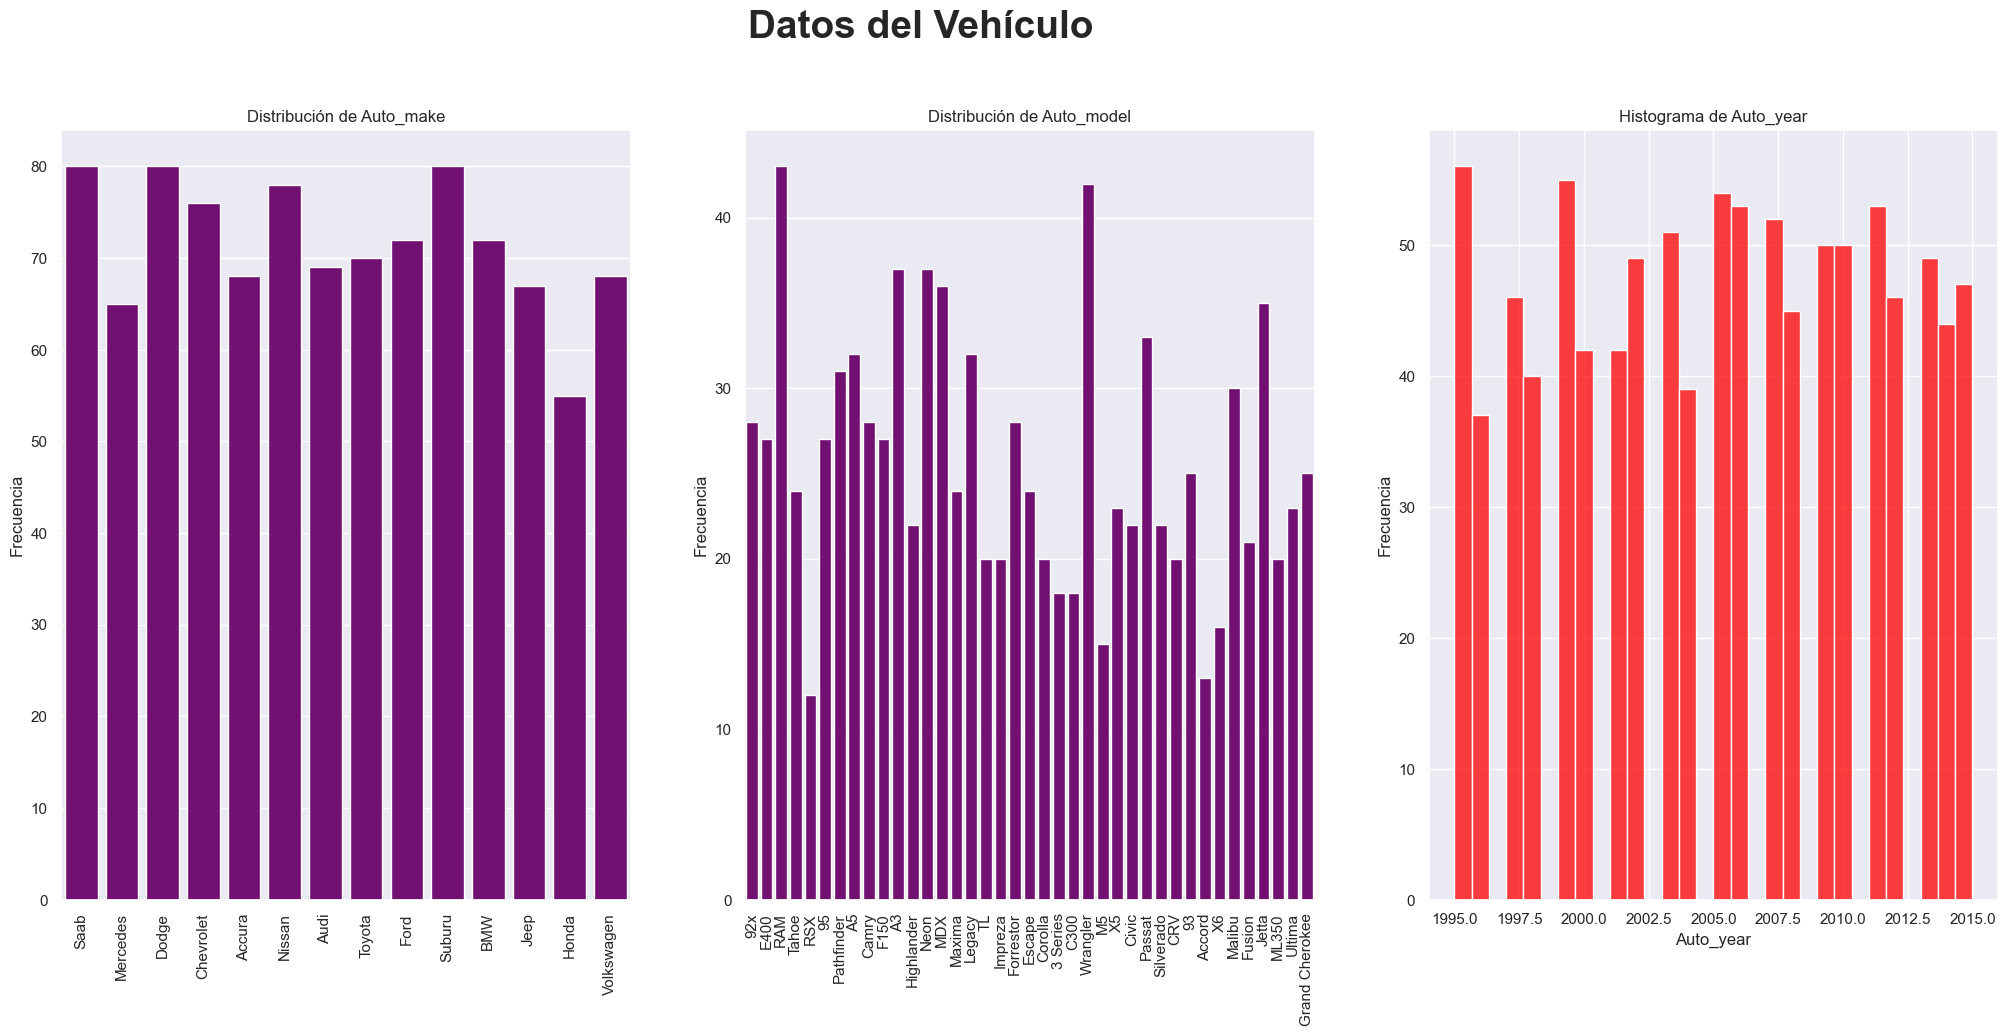

In [16]:
#Gráficas para Datos del Vehículo:
variables = ["auto_make","auto_model","auto_year"]
df_filtrado = df[variables]


fig, axes= plt.subplots(nrows = 1, ncols = 3,figsize=(25, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    # Trabajamos sobre el eje correspondiente
    ax = axes[i]  
    # Si la variable es categórica, hacemos un grafico de barras
        # Si hay varias categorias rotamos las etiquetas
    if df_filtrado[var].dtype == "object":
        if df_filtrado[var].nunique() > 5:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )

            ax.tick_params(axis='x', rotation=90)
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
        else:
            sns.countplot(
                x=var,  
                data=df_filtrado, 
                ax=ax,
                color = "purple"
            )
            # Ajustamos títulos y etiquetas
            ax.set_title(f"Distribución de {var.capitalize()}")
            ax.set_xlabel("")
            ax.set_ylabel("Frecuencia")
    # Si la variable es numérica, hacemos un histograma
    else:
        # Calcular los bins automáticamente para variables numéricas/discretas
        bins_choise = (
            len(df_filtrado[var].unique())
            if "año" in var or "fecha" in var or df_filtrado[var].nunique() < 2
            else 30
        )
        sns.histplot(
            data=df_filtrado, 
            x=var, 
            bins=bins_choise, 
            ax=ax, 
            color = "red"
        )
        # Ajustamos títulos y etiquetas
        ax.set_title(f"Histograma de {var.capitalize()}")
        ax.set_xlabel(var.capitalize())
        ax.set_ylabel("Frecuencia")
    
    # Quitamos la leyenda individual de cada gráfico para que no estorbe
    if ax.get_legend():
        ax.get_legend().remove()

fig.suptitle("Datos del Vehículo", 
             fontsize=28, fontweight='bold', x=0.4, ha='left', y=1)

plt.show()

### Análisis Variable Objetivo (AGREGAR)

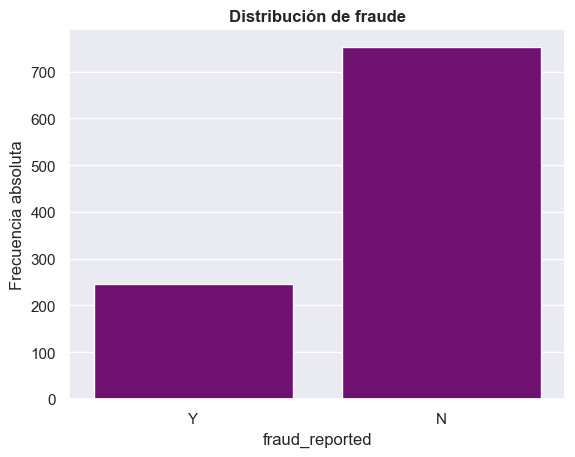

In [17]:
# Gráfica para analizar variable objetivo (Podemos escoger el gráfico que más les agrade)
sns.countplot(data=df, x='fraud_reported', color = "purple")
plt.title('Distribución de fraude', fontweight='bold')
plt.xlabel('fraud_reported')
plt.ylabel('Frecuencia absoluta')
plt.show()


conteo = df['fraud_reported'].value_counts()

fig = go.Figure()

fig.add_trace(
    go.Bar(
        x=conteo.index,
        y=conteo.values,
        marker_color=px.colors.qualitative.Plotly[:len(conteo)],
        opacity=0.92,
        text=conteo.values,
        textposition='outside',
        texttemplate='%{text:,.0f}',
        cliponaxis=False,
        hovertemplate='<b>%{x}</b><br>Pólizas: %{y:,.0f}<extra></extra>'
    )
)

fig.update_layout(
    title='Insurance: distribución fraud_reported',
    xaxis_title='fraud_reported',
    yaxis_title='Frecuencia absoluta',
    width=1000,
    height=600
)

fig.show()

---
<a id='3-rel_fraude'></a>
# 3 Relación con el Fraude

### Análisis inicial (AGREGAR)

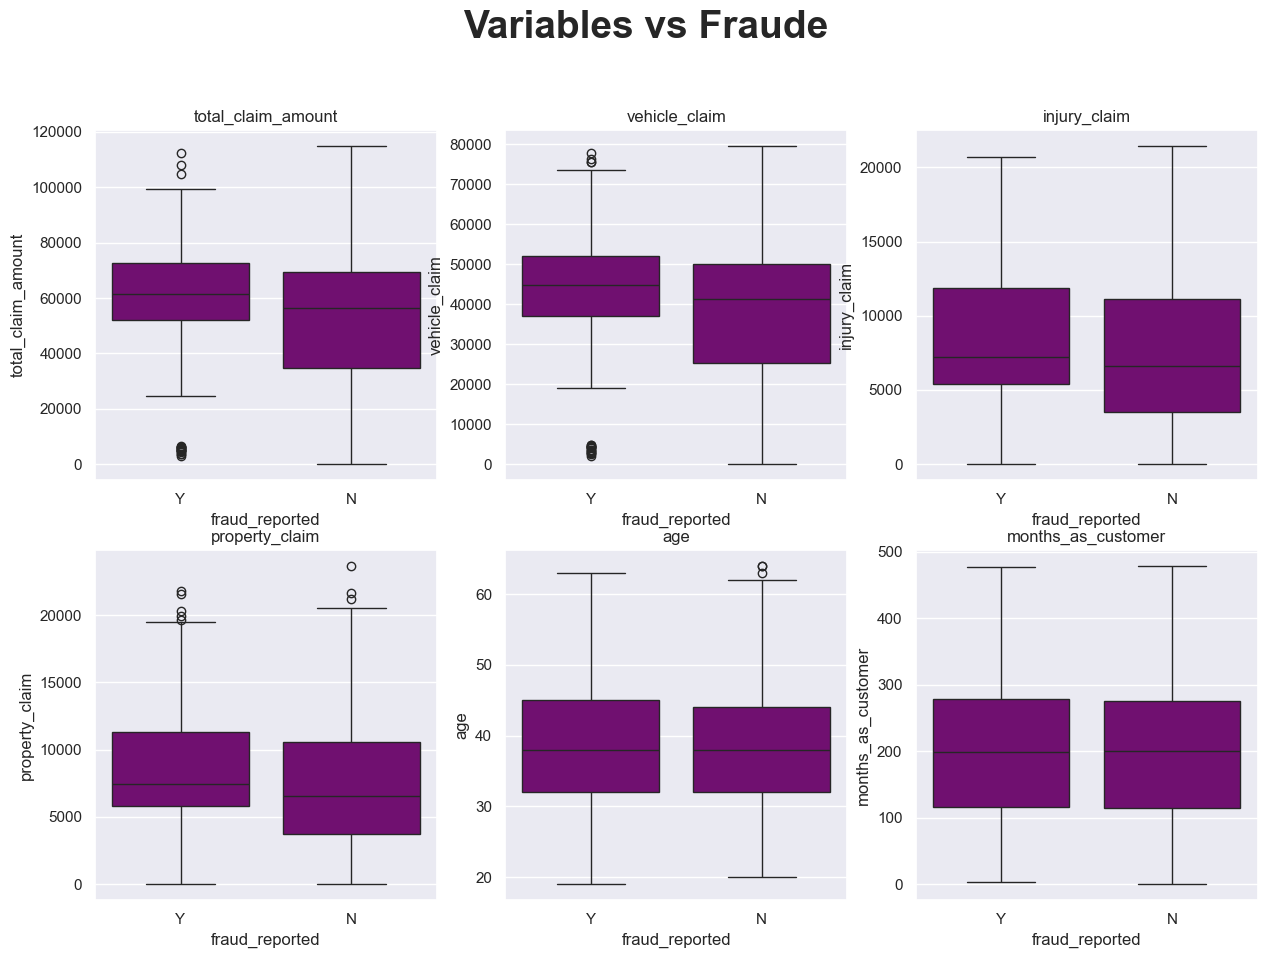

In [18]:
# Análisis de variables de acuerdo a categorización de fraude
variables = [
'total_claim_amount',
'vehicle_claim',
'injury_claim',
'property_claim',
'age',
'months_as_customer'
]

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15,10))
for var,axes in zip(variables, axes.flat):
    sns.boxplot(data=df, x='fraud_reported', y=var, ax=axes, color = 'purple')
    axes.set_title(var)

fig.suptitle("Variables vs Fraude", 
             fontsize=28, fontweight='bold', x=0.37, ha='left', y=1)

plt.show()

### Agregar comentarios

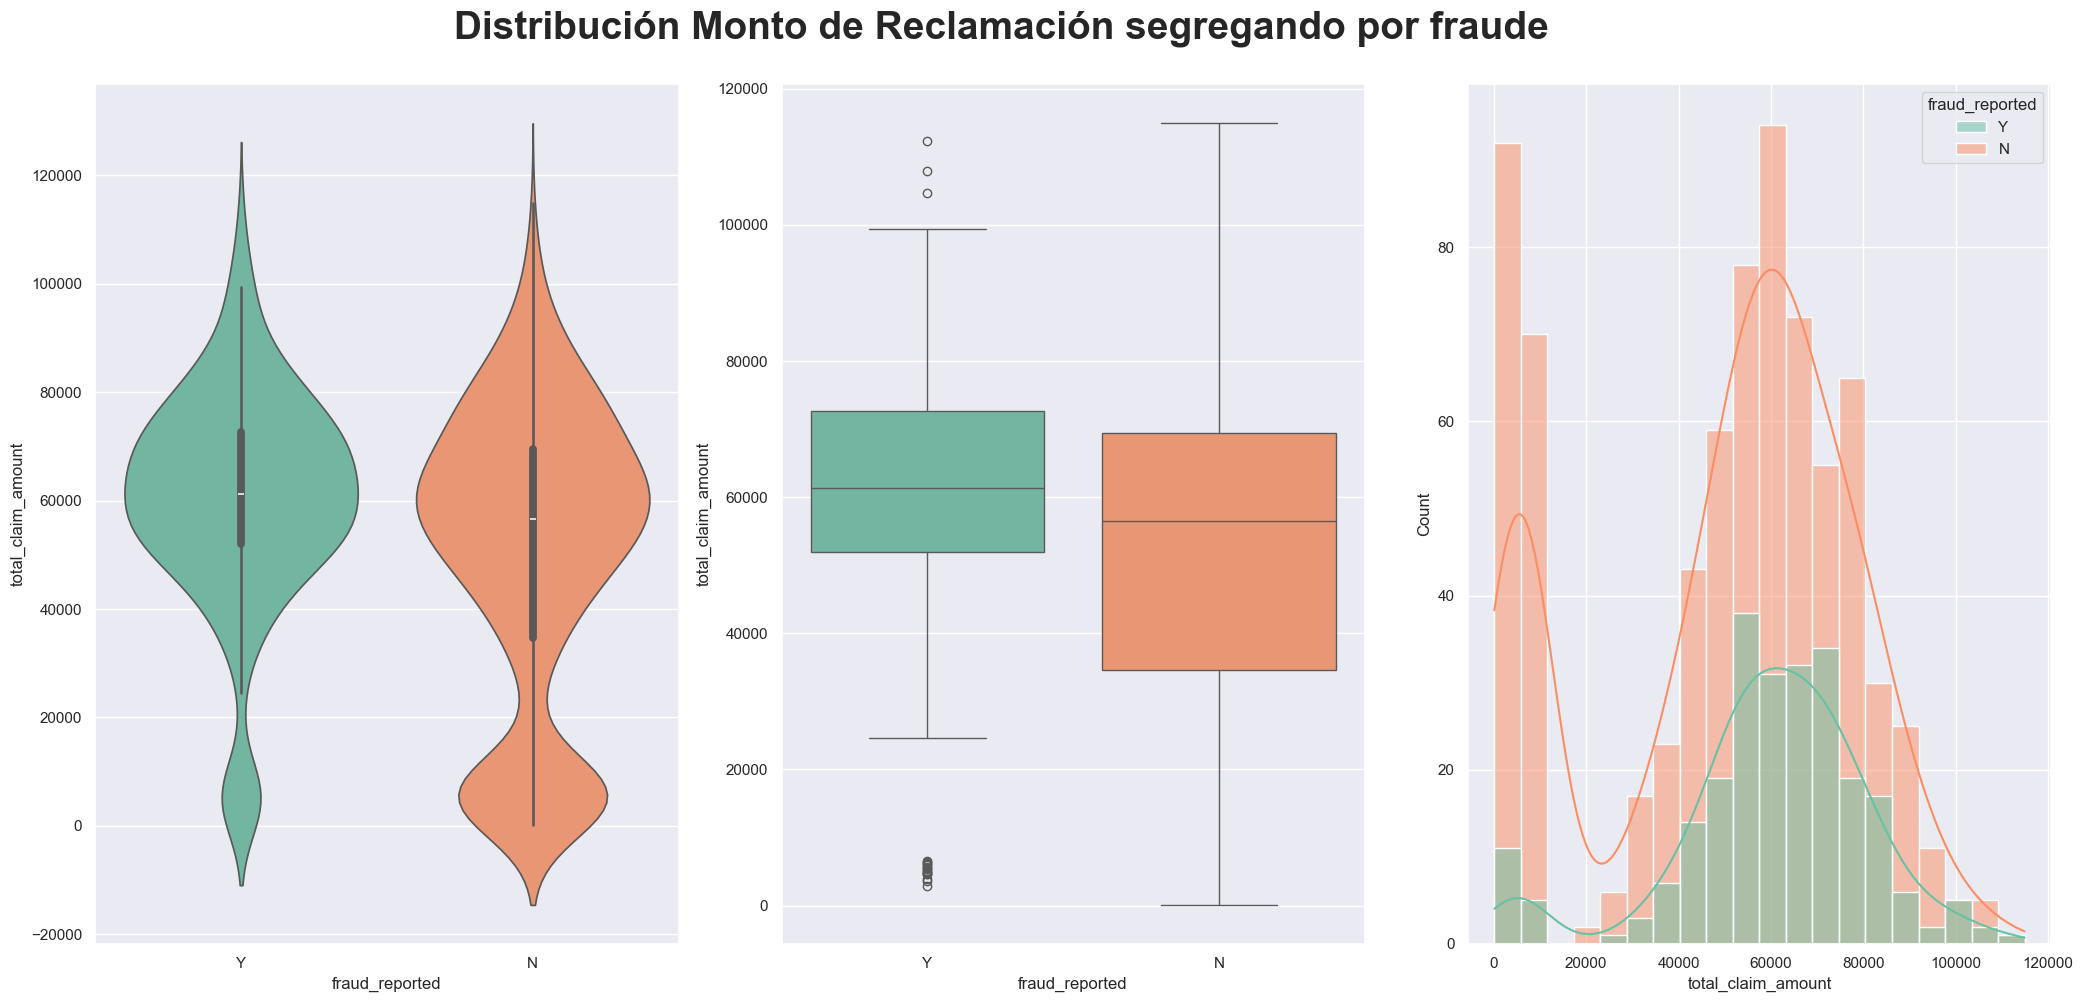

In [20]:
# Siniestralidad de acuerdo a etiqueta de Fraude
fig, axes = plt.subplots(nrows=1, ncols=3,figsize=(21, 10))

sns.violinplot(
    data=df,
    x="fraud_reported",
    y="total_claim_amount",
    hue="fraud_reported",
    palette="Set2",
    inner="box",      # agrega boxplot interno
    legend=False,
    ax = axes[0]
)


sns.boxplot(data=df, 
                      x="fraud_reported", 
                      hue="fraud_reported",
                      y="total_claim_amount", 
                      palette="Set2",
                      ax = axes[1])


sns.histplot(data=df,
             x = "total_claim_amount",
             hue = "fraud_reported",
             palette = "Set2",
             ax = axes[2],
             kde = True)



fig.suptitle("Distribución Monto de Reclamación segregando por fraude", 
             fontsize=28, fontweight='bold', x=0.22, ha='left', y=1)
plt.tight_layout()
plt.show()

### Agregar comentario

In [21]:
# Función para crear subplot con px
def agregar_grafico_a_subplot(
    df, columna_caracteristica, fig_subplots, fila, columna, columna_fraude="fraud_reported"
):
    """
    Función que genera gráficos exprés temporales y donde se define un subplot global donde se van metiendo todos los temporales\n

    Parámetros:
    -----------
    - df: El DataFrame que contiene los datos
    - columna_caracteristica: (str) Nombre de la columna a analizar
    - fig_subplots: (variable tipo gráfico [make_subplots]) Figura global donde se insertarán todos los gráficos que se crearon temporalmente
    - fila: (int) Índice de la fila de la cuadrícula donde se insertará el gráfico
    - columna: (int) Índice de la columna de la cuadrícula donde se insertará el gráfico
    - columna_fraude: (str) Nombre de la columna objetivo
    """

    # Tabla  Contingente
    tabla = pd.crosstab(
        df[columna_caracteristica], df[columna_fraude], normalize="index"
    ).reset_index()
    # Tabla a formato largo
    tabla_long = tabla.melt(
        id_vars=columna_caracteristica,
        var_name=columna_fraude,
        value_name="proporcion",
    )

    # Creamos un grafico temporal con Plotly Express
    fig_temporal = px.bar(
        tabla_long,
        x=columna_caracteristica,
        y="proporcion",
        color=columna_fraude,
        barmode="stack",
        text_auto=".1%",
    )

    # Mover los trazos del gráfico temporal al subplot global
    for trace in fig_temporal.data:
        # Si no es la primera celda (1,1), desactivamos la leyenda para evitar que se duplique
        if fila > 1 or columna > 1:
            trace.showlegend = False
        # Por como funciona px, agregamos el grafico temporal a uno que tenga todos
        fig_subplots.add_trace(trace, row=fila, col=columna)

    # 4. Actualizar los títulos de los ejes para esta cuadrícula específica
    fig_subplots.update_xaxes(title_text=columna_caracteristica, row=fila, col=columna)

In [25]:
# Creamos gráficos de proporciones por Fraude

variables_a_analizar = [
    "insured_education_level",
    "insured_hobbies",
    "insured_sex",
    "incident_severity",
    "incident_city",
    "collision_type",
    "incident_hour_of_the_day",
    'insured_occupation',
    
]

# Definimos la estructura en la que se presentará el gráfico
filas = 2
columnas = 4

fig_global = make_subplots(
    rows=filas,
    cols=columnas,
    subplot_titles=[f"Fraude por {var}" for var in variables_a_analizar],
    shared_yaxes=True,  # Compartir el eje Y para comparar proporciones fácilmente
)

# 3. (usamos enumerate para saber en qué fila/columna meter cada gráfica)
for indice, caracteristica in enumerate(variables_a_analizar):
    # Calcular la posición en la matriz (1-indexed para Plotly)
    fila = (indice // columnas) + 1
    columna = (indice % columnas) + 1

    # Ponemos el gráfico de la característica actual en el lienzo global
    agregar_grafico_a_subplot(
        df=df,
        columna_caracteristica=caracteristica,
        fig_subplots=fig_global,
        fila=fila,
        columna=columna,
    )

# Ajustes finales de la gráfica global
fig_global.update_layout(
    title_text="Análisis de Proporciones de Fraude",
    height=1000,  # Ajusta el alto total para que no se amontonen
    width=1800,  # Ajusta el ancho total
    barmode="stack",  # Asegura que todos los subplots mantengan el estilo apilado
    yaxis_tickformat=".0%",
)

fig_global.show()

,incident_hour_of_the_day,n,fraudes,tasa_fraude,tasa_fraude_pct
0,0,52,12,0.230769,23.076923
1,1,29,8,0.275862,27.586207
2,2,31,10,0.322581,32.258065
3,3,53,12,0.226415,22.641509
4,4,46,8,0.173913,17.391304
5,5,33,9,0.272727,27.272727
6,6,44,14,0.318182,31.818182
7,7,40,8,0.200000,20.000000
8,8,36,6,0.166667,16.666667
9,9,43,4,0.093023,9.302326


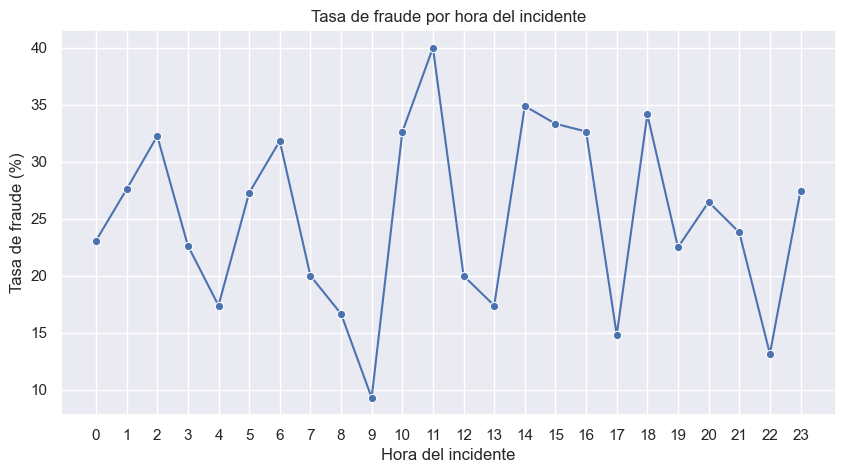

In [29]:
# Tasa de fraude por hora del incidente (arriba ya se puso, cuál prefieren?)
df['fraud_ind'] = df['fraud_reported'].map({'Y': 1, 'N': 0})
tabla_hora = (
    df.groupby("incident_hour_of_the_day")
      .agg(
          n=("fraud_ind", "size"),
          fraudes=("fraud_ind", "sum"),
          tasa_fraude=("fraud_ind", "mean")
      )
      .reset_index()
)

tabla_hora["tasa_fraude_pct"] = 100 * tabla_hora["tasa_fraude"]

display(tabla_hora)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=tabla_hora,
    x="incident_hour_of_the_day",
    y="tasa_fraude_pct",
    marker="o"
)

plt.title("Tasa de fraude por hora del incidente")
plt.xlabel("Hora del incidente")
plt.ylabel("Tasa de fraude (%)")
plt.xticks(range(0, 24))
plt.show()

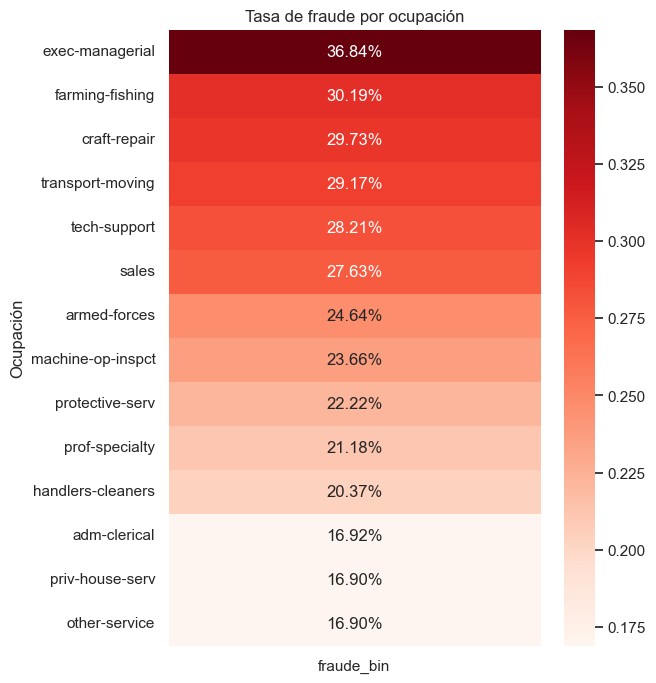

In [30]:
# (arriba ya se puso, cuál prefieren?)
df['fraude_bin'] = (df['fraud_reported'] == 'Y').astype(int)

# Tasa de fraude por ocupación
heat = (
    df.groupby('insured_occupation')['fraude_bin']
      .mean()
      .sort_values(ascending=False)
      .to_frame()
)

plt.figure(figsize=(6,8))

sns.heatmap(
    heat,
    annot=True,
    fmt='.2%',
    cmap='Reds'
)

plt.title('Tasa de fraude por ocupación')
plt.xlabel('')
plt.ylabel('Ocupación')

plt.show()

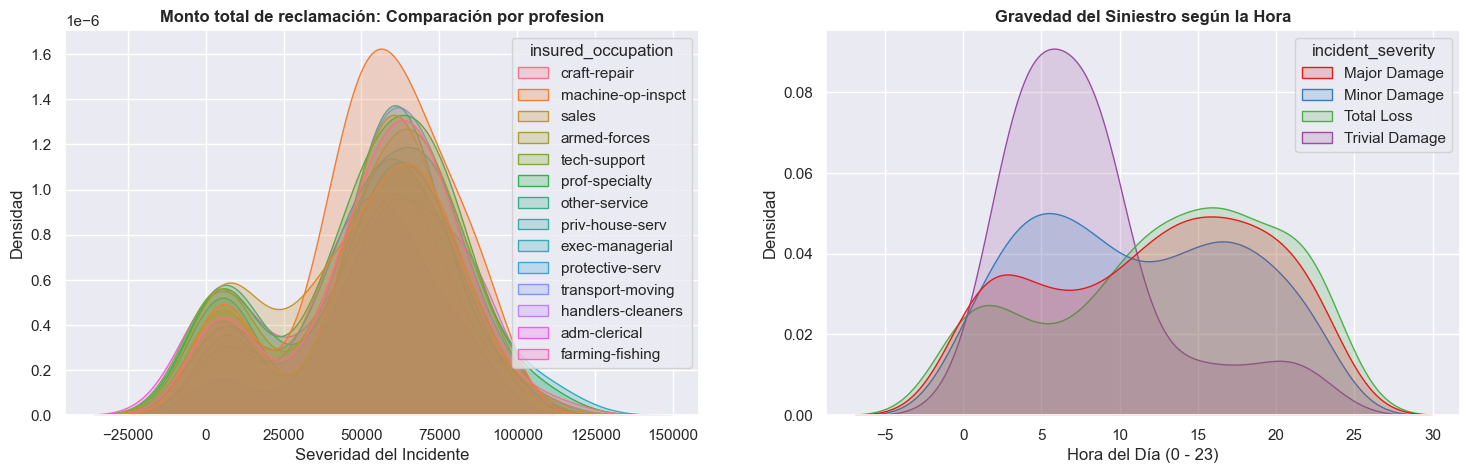

In [31]:
#insured_occupation 
#Comparación de poblaciones a través de densidades: charges por sexo

fig, axes = plt.subplots(1, 2, figsize=(18, 5))


sns.kdeplot(data=df, x="total_claim_amount", hue="insured_occupation", fill=True, ax = axes[0])
axes[0].set_title('Monto total de reclamación: Comparación por profesion', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Severidad del Incidente')
axes[0].set_ylabel('Densidad')

sns.kdeplot(data=df, x='incident_hour_of_the_day', hue='incident_severity', common_norm=False, fill=True, palette='Set1', alpha=0.2, ax=axes[1])
axes[1].set_title('Gravedad del Siniestro según la Hora', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hora del Día (0 - 23)')
axes[1].set_ylabel('Densidad')

plt.show()

---
<a id='4-temporal'></a>
# Pasos que faltan para profundizar:

 - **Completar análisis actual:** Revisar la asimetria, curtosis y sesgo de las distribuciones que hemos graficado.

 - **Análisis de NA's:** En general no hay NA's en el dataframe, sin embargo, hay 3 variables que detallan el siniestro que tienen una cantididad significativa de registros '?', se podria analizar si tiene sentido esto o se debe a algun error que debamos gestionar.

 - **Análisis de Siniestralidad por grupos con mayor fraude:** Esto permite analizar el impacto que tienen estos eventos.

 - **Análisis de Correlación entre variables:** Esto debe de ser coherente con todo lo que hemos analizado con anterioridad (se debe hacer encoding con las variables categoricas)

 - **Pruebas de hipotesis:** Se deben realizar pruebas de hipótesis sobre los comportamientos que observamos en los gráficos
    - **Prueba de Chi-Square Statistic:** Existe asociación estadísticamente significativa entre las variables (Esta prueba de hipotesis se puede usar en todo el apartado donde hacemos gráficos de porcentaje de fraude)

    - **Prueba no paramétrica U de Mann-witney o Prueba de homogeneidad de varianza (levene y bartlett):** Comparación de poblaciones (Si hacemos el análisis de Siniestralidad) podemos realizar pueba para ver si la siniestralidad difiere por grupos fraudulentos o no.

- **Bootstrap**

# Conclusiones:

Para la prueba de Chi-Cuadrada el p-value es mayor que 0.05, podemos rechazar la hipotesis nula, por lo que nuestras variables no son significativas respecto a las etiquetas de fraude y no fraude. 

Para las pruebas de Mann-Whitney y Leven observemos que se rech

Pruebas Chi-cuadrada: variables categóricas vs fraude


,variable,chi2,grados_libertad,p_value,significativa_5pct,min_frecuencia_esperada
5,months_as_customer,419.685182,390,0.144391,False,0.247
1,vehicle_claim,764.773564,725,0.148376,False,0.247
4,age,50.828585,45,0.254845,False,0.247
3,property_claim,647.535294,625,0.258269,False,0.247
2,injury_claim,644.783119,637,0.406780,False,0.247
0,total_claim_amount,766.834596,762,0.444073,False,0.247


Pruebas Mann-Whitney y Levene: variables numéricas por fraude


c:\Users\ismae\anaconda3\envs\diplomado\Lib\site-packages\scipy\stats\_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom


,variable,media_no_fraude,media_fraude,mediana_no_fraude,mediana_fraude,diferencia_media_fraude_menos_no_fraude,p_mann_whitney,mw_significativa_5pct,p_levene,varianzas_distintas_5pct
18,fraude_bin,0.000000e+00,1.000000e+00,0.00,1.00,1.000000,0.000000,True,NaN,False
14,vehicle_claim,3.609049e+04,4.353364e+04,41220.00,44800.00,7443.152357,0.000006,True,0.000000,True
16,siniestralidad_total,5.028861e+04,6.030211e+04,56520.00,61290.00,10013.499685,0.000011,True,0.000000,True
11,total_claim_amount,5.028861e+04,6.030211e+04,56520.00,61290.00,10013.499685,0.000011,True,0.000000,True
13,property_claim,7.018884e+03,8.560121e+03,6560.00,7440.00,1541.236995,0.000024,True,0.252330,False
12,injury_claim,7.179230e+03,8.208340e+03,6620.00,7240.00,1029.110333,0.005498,True,0.055657,False
4,umbrella_limit,1.023904e+06,1.336032e+06,0.00,0.00,312128.006194,0.057696,False,0.066058,False
8,number_of_vehicles_involved,1.808765e+00,1.931174e+00,1.00,1.00,0.122409,0.103105,False,0.101352,False
10,witnesses,1.455511e+00,1.582996e+00,1.00,2.00,0.127485,0.114650,False,0.117685,False
9,bodily_injuries,9.760960e-01,1.040486e+00,1.00,1.00,0.064390,0.285335,False,0.530983,False


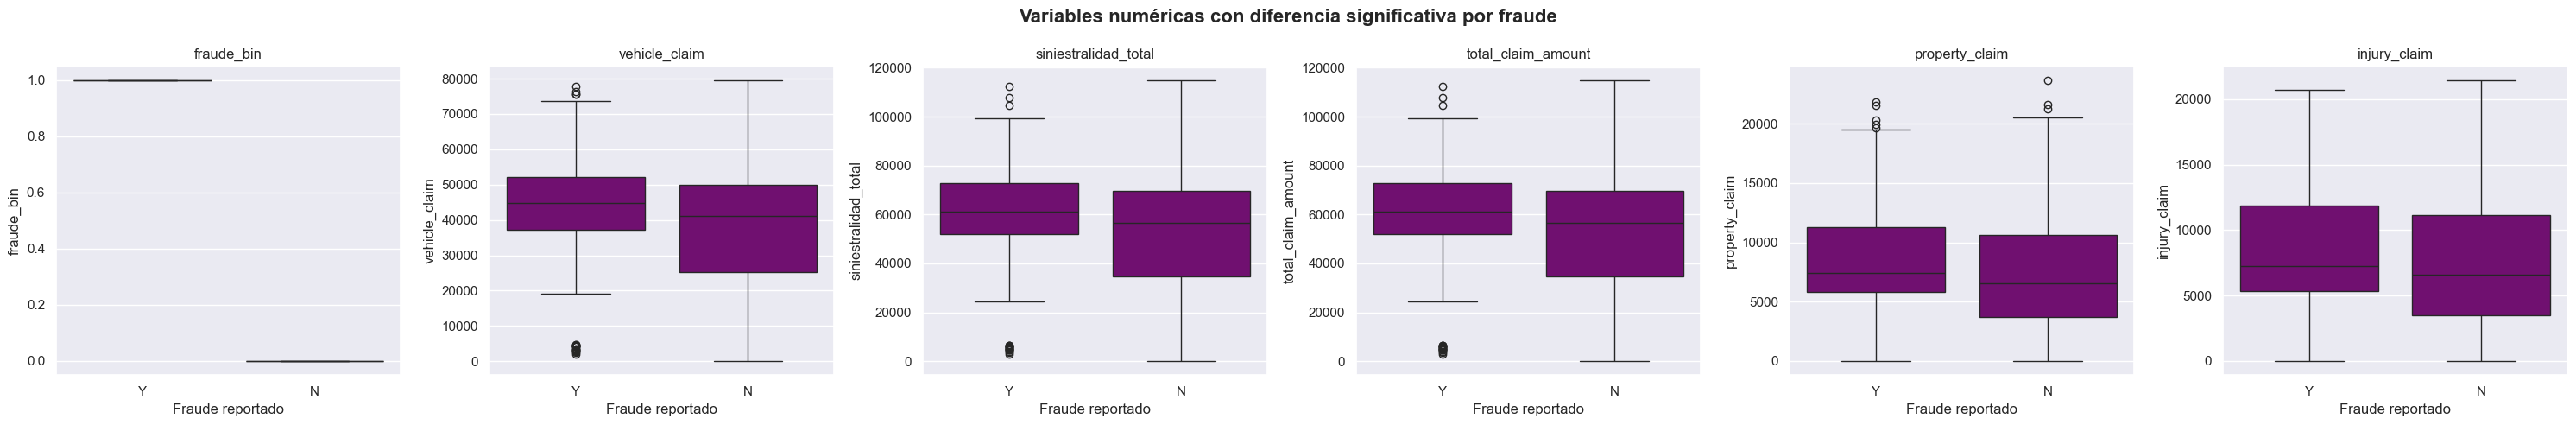

In [32]:
# ============================================================
# 4.5 Pruebas de hipótesis
# ============================================================
from scipy.stats import levene

# A) Chi-cuadrada: variables categóricas vs fraude
variables_categoricas = [
'total_claim_amount',
'vehicle_claim',
'injury_claim',
'property_claim',
'age',
'months_as_customer'
]

pruebas_chi = []

for col in variables_categoricas:
    serie = df[col].replace("?", "SIN_DATO").fillna("SIN_DATO")
    tabla = pd.crosstab(serie, df["fraud_reported"])

    if tabla.shape[0] > 1 and tabla.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(tabla)
        pruebas_chi.append({
            "variable": col,
            "chi2": chi2,
            "grados_libertad": dof,
            "p_value": p_value,
            "significativa_5pct": p_value < 0.05,
            "min_frecuencia_esperada": expected.min()
        })

pruebas_chi = pd.DataFrame(pruebas_chi).sort_values("p_value")

print("Pruebas Chi-cuadrada: variables categóricas vs fraude")
display(pruebas_chi.round(6))

# B) Mann-Whitney y Levene: variables numéricas por fraude
variables_numericas_prueba = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in ["policy_number", "insured_zip", "fraud_ind"]
]

pruebas_numericas = []

for col in variables_numericas_prueba:
    grupo_no_fraude = df.loc[df["fraud_reported"] == "N", col].dropna()
    grupo_fraude = df.loc[df["fraud_reported"] == "Y", col].dropna()

    if len(grupo_no_fraude) > 0 and len(grupo_fraude) > 0:
        stat_mw, p_mw = mannwhitneyu(
            grupo_no_fraude,
            grupo_fraude,
            alternative="two-sided"
        )

        stat_lev, p_lev = levene(
            grupo_no_fraude,
            grupo_fraude,
            center="median"
        )

        pruebas_numericas.append({
            "variable": col,
            "media_no_fraude": grupo_no_fraude.mean(),
            "media_fraude": grupo_fraude.mean(),
            "mediana_no_fraude": grupo_no_fraude.median(),
            "mediana_fraude": grupo_fraude.median(),
            "diferencia_media_fraude_menos_no_fraude": grupo_fraude.mean() - grupo_no_fraude.mean(),
            "p_mann_whitney": p_mw,
            "mw_significativa_5pct": p_mw < 0.05,
            "p_levene": p_lev,
            "varianzas_distintas_5pct": p_lev < 0.05
        })

pruebas_numericas = pd.DataFrame(pruebas_numericas).sort_values("p_mann_whitney")

print("Pruebas Mann-Whitney y Levene: variables numéricas por fraude")
display(pruebas_numericas.round(6))

# Visual para las variables numéricas con diferencia significativa por Mann-Whitney
vars_significativas = (
    pruebas_numericas
    .query("mw_significativa_5pct == True")
    .sort_values("p_mann_whitney")
    ["variable"]
    .head(6)
    .tolist()
)

if len(vars_significativas) > 0:
    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(vars_significativas),
        figsize=(5 * len(vars_significativas), 5)
    )

    if len(vars_significativas) == 1:
        axes = [axes]

    for ax, col in zip(axes, vars_significativas):
        sns.boxplot(
            data=df,
            x="fraud_reported",
            y=col,
            ax=ax,
            color="purple"
        )
        ax.set_title(col)
        ax.set_xlabel("Fraude reportado")

    fig.suptitle("Variables numéricas con diferencia significativa por fraude", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# EXPORTAR FIGURAS PARA EL PDF
# ============================================================
import os
os.makedirs("figuras_pdf", exist_ok=True)
print("Carpeta figuras_pdf/ lista")

In [33]:
#botrstrap : diferencia en tasa de fraude por sexo del asegurado (estimacion puntual + IC 95)
n_boot = 10000
categorias = sorted(df['insured_sex'].unique())
cat_female, cat_male = categorias[0], categorias[1]

grupo_f = df.loc[df['insured_sex'] == cat_female, 'fraud_ind'].values  
grupo_m = df.loc[df['insured_sex'] == cat_male,   'fraud_ind'].values  

#valor puntual observado (calculado una sola ve sobre los datos originales)
tasa_f, tasa_m = grupo_f.mean(), grupo_m.mean()
diff_obs = tasa_f - tasa_m

#remuestreo bootstrap
boot_f = rng.choice(grupo_f, size=(n_boot, len(grupo_f)), replace=True).mean(axis=1)
boot_m = rng.choice(grupo_m, size=(n_boot, len(grupo_m)), replace=True).mean(axis=1)
diffs_boot = boot_f - boot_m

ic_inf, ic_sup = np.percentile(diffs_boot, [2.5, 97.5])
error_estandar = diffs_boot.std()

print(f"Tasa de fraude ({cat_female}): {tasa_f:.2%}")
print(f"Tasa de fraude ({cat_male}): {tasa_m:.2%}")
print(f"Diferencia observada ({cat_female} - {cat_male}): {diff_obs:.2%}")
print(f"Error estándar bootstrap: {error_estandar}")
print(f"IC 95% bootstrap: [{ic_inf}, {ic_sup}]")

Tasa de fraude (FEMALE): 23.46%
Tasa de fraude (MALE): 26.13%
Diferencia observada (FEMALE - MALE): -2.67%
Error estándar bootstrap: 0.02737543944321663
IC 95% bootstrap: [-0.08099573263189222, 0.027371787910598407]


Resultado muy util ya que si encerramos al 0 en nuestro intervalo de confianza podemos decir que hay evidencia estadística que la diferencia de tasas es 0, es decir ambas tasas son iguales.